In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iambahar/ffffddddds/MI_NonMI_Patient_Dataset.xlsx


# handling missing value

In [2]:
import pandas as pd
df=pd.read_excel('/kaggle/input/datasets/iambahar/ffffddddds/MI_NonMI_Patient_Dataset.xlsx')


# ── Step 1: Split Blood Pressure ─────────────────────────────────────────────
bp = df['Blood_Pressure_mmHg'].astype(str).str.extract(r'(\d+)/(\d+)')
df['Systolic_BP']  = pd.to_numeric(bp[0], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(bp[1], errors='coerce')
df.drop(columns=['Blood_Pressure_mmHg'], inplace=True)
print("\n[1] Split Blood_Pressure_mmHg → Systolic_BP, Diastolic_BP ✓")

# ── Step 1b: Drop CK_MB_UL and BNP_pgmL (excessive missingness) ──────────────
#    Both columns are missing for a large share of the dataset. Per-phase
#    median imputation would effectively fabricate most of their values, so
#    they are removed entirely rather than imputed.
drop_cols = [c for c in ['CK_MB_UL', 'BNP_pgmL'] if c in df.columns]
if drop_cols:
    print(f"\n[1b] Dropping columns with excessive missingness: {drop_cols}")
    for c in drop_cols:
        n_miss = df[c].isna().sum()
        print(f"     '{c}': {n_miss}/{len(df)} missing "
              f"({n_miss/len(df)*100:.1f}%) → column dropped")
    df.drop(columns=drop_cols, inplace=True)

# ── Step 1c: Drop rows with missing hs_Troponin_I_ngL ────────────────────────
#    Troponin is the primary biomarker tied to the Phase label, so it is kept
#    and rows missing it are removed via listwise deletion rather than imputed.
if 'hs_Troponin_I_ngL' in df.columns:
    before_n = len(df)
    n_miss_trop = df['hs_Troponin_I_ngL'].isna().sum()
    df = df.dropna(subset=['hs_Troponin_I_ngL']).reset_index(drop=True)
    print(f"\n[1c] Dropped {n_miss_trop} rows with missing hs_Troponin_I_ngL "
          f"({before_n} → {len(df)} rows)")

df_mode = df.copy()      # Dataset 1
df_missing = df.copy()   # Dataset 2

NUM_COLS_RAW = ['Age', 'hs_Troponin_I_ngL',
                'Blood_Glucose_mmolL', 'Serum_Creatinine_mgdL',
                'Heart_Rate_bpm', 'Systolic_BP', 'Diastolic_BP']

NUM_COLS_RAW = [c for c in NUM_COLS_RAW if c in df_mode.columns]

for dataset in [df_mode, df_missing]:

    for col in NUM_COLS_RAW:

        if dataset[col].isna().sum() > 0:

            # Phase + Sex median
            dataset[col] = dataset.groupby(
                ['Phase', 'Sex']
            )[col].transform(
                lambda x: x.fillna(x.median())
            )

            # Fallback: Phase median
            dataset[col] = dataset.groupby(
                'Phase'
            )[col].transform(
                lambda x: x.fillna(x.median())
            )

            # Final fallback: global median
            dataset[col] = dataset[col].fillna(
                dataset[col].median()
            )

CAT_BIN_COLS = ['Sex', 'Chest_Pain', 'Shortness_of_Breath',
                'Nausea', 'Sweating', 'Hypertension',
                'Diabetes_Mellitus', 'Smoking',
                'Hyperlipidaemia', 'Prior_MI',
                'Family_History_CAD']

for col in CAT_BIN_COLS:

    df_mode[col] = df_mode.groupby(
        ['Phase', 'Sex']
    )[col].transform(
        lambda x: x.fillna(x.mode().iloc[0])
        if not x.mode().empty else x
    )

    df_mode[col] = df_mode.groupby(
        'Phase'
    )[col].transform(
        lambda x: x.fillna(x.mode().iloc[0])
        if not x.mode().empty else x
    )

    df_mode[col] = df_mode[col].fillna(
        df_mode[col].mode().iloc[0]
    )

for col in CAT_BIN_COLS:
    df_missing[col] = df_missing[col].fillna("Missing")

df_mode.to_excel(
    "dataset_phase_sex_mode.xlsx",
    index=False
)

df_missing.to_excel(
    "dataset_phase_sex_missing.xlsx",
    index=False
)


[1] Split Blood_Pressure_mmHg → Systolic_BP, Diastolic_BP ✓

[1b] Dropping columns with excessive missingness: ['CK_MB_UL', 'BNP_pgmL']
     'CK_MB_UL': 1862/1960 missing (95.0%) → column dropped
     'BNP_pgmL': 1714/1960 missing (87.4%) → column dropped

[1c] Dropped 60 rows with missing hs_Troponin_I_ngL (1960 → 1900 rows)


# label encoding

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# =============================================================
# LOAD DATA
# =============================================================
df_mode = pd.read_excel("/kaggle/working/dataset_phase_sex_mode.xlsx")
df_missing = pd.read_excel("/kaggle/working/dataset_phase_sex_missing.xlsx")

# =============================================================
# FIX DTYPES + LABEL ENCODING
# =============================================================
def fix_dtypes_and_encode(df, num_cols, cat_cols):
    df = df.copy()

    # Numeric columns
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

    # Categorical columns
    for col in cat_cols:
        if df[col].dtype == object:
            le = LabelEncoder()

            nan_mask = df[col].isna()

            df[col] = le.fit_transform(df[col].astype(str))

            # Restore NaN
            df.loc[nan_mask, col] = np.nan

        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


# =============================================================
# FILL NULLS
# =============================================================
def fill_nulls(df, num_cols, cat_cols):
    df = df.copy()

    for col in num_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in cat_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    return df


# =============================================================
# PROCESS
# =============================================================
df_mode_encoded = fix_dtypes_and_encode(
    df_mode,
    NUM_COLS_RAW,
    CAT_BIN_COLS
)

df_missing_encoded = fix_dtypes_and_encode(
    df_missing,
    NUM_COLS_RAW,
    CAT_BIN_COLS
)

df_mode_encoded = fill_nulls(
    df_mode_encoded,
    NUM_COLS_RAW,
    CAT_BIN_COLS
)

df_missing_encoded = fill_nulls(
    df_missing_encoded,
    NUM_COLS_RAW,
    CAT_BIN_COLS
)

# =============================================================
# SAVE
# =============================================================
mode_file = "mode_label_encoded.xlsx"
missing_file = "missing_label_encoded.xlsx"

df_mode_encoded.to_excel(mode_file, index=False)
df_missing_encoded.to_excel(missing_file, index=False)

print("Saved:")
print(mode_file)
print(missing_file)

Saved:
mode_label_encoded.xlsx
missing_label_encoded.xlsx


# feature engineering

In [4]:
import numpy as np
import pandas as pd

# =============================================================
# WEIGHTS — edit these anytime
# =============================================================

SYMPTOM_WEIGHTS = {
    'Chest_Pain':          4,
    'Shortness_of_Breath': 1,
    'Nausea':              1,
    'Sweating':            1,
}

RISK_WEIGHTS = {
    'Prior_MI':           1,
    'Hypertension':       1,
    'Diabetes_Mellitus':  1,
    'Smoking':            1,
    'Hyperlipidaemia':    1,
    'Family_History_CAD': 1,
}

# =============================================================
# FEATURE ENGINEERING
# =============================================================

print("=" * 55)
print("  ORIGINAL FEATURES")
print("=" * 55)
print(df.columns.tolist())
print(f"\n  Shape: {df.shape}")

df_fe = df_mode_encoded.copy()

# A. Pulse Pressure (SBP - DBP)
df_fe['Pulse_Pressure'] = df_fe['Systolic_BP'] - df_fe['Diastolic_BP']

# B. Weighted Symptom Score
df_fe['Weighted_Symptom_Score'] = sum(
    df_fe[col] * w for col, w in SYMPTOM_WEIGHTS.items()
)

# C. Weighted Risk Score
df_fe['Weighted_Risk_Score'] = sum(
    df_fe[col] * w for col, w in RISK_WEIGHTS.items()
)

# D. Age-Adjusted Troponin (Age * ln(Troponin + 1))
df_fe['Age_Adjusted_Troponin'] = df_fe['Age'] * np.log1p(df_fe['hs_Troponin_I_ngL'])

# =============================================================
# PRINT
# =============================================================

NEW_COLS = ['Pulse_Pressure', 'Weighted_Symptom_Score',
            'Weighted_Risk_Score', 'Age_Adjusted_Troponin']

print("\n" + "=" * 55)
print("  NEW ENGINEERED FEATURES")
print("=" * 55)
print(NEW_COLS)

print("\n" + "=" * 55)
print("  WEIGHT REFERENCE")
print("=" * 55)
print("\n  Symptom weights:")
for col, w in SYMPTOM_WEIGHTS.items():
    print(f"    {col:<25} {w}")
print("\n  Risk factor weights:")
for col, w in RISK_WEIGHTS.items():
    print(f"    {col:<25} {w}")

print("\n" + "=" * 55)
print("  ENGINEERED DATASET PREVIEW")
print("=" * 55)
print(df_fe[NEW_COLS].head(10).to_string())
print(f"\n  Final shape: {df_fe.shape}")

# Save
df_fe.to_excel('mode_engineered.xlsx', index=False)
print("\n  Saved → mode_engineered.xlsx")

  ORIGINAL FEATURES
['Phase', 'Age', 'Sex', 'Chest_Pain', 'Shortness_of_Breath', 'Nausea', 'Sweating', 'hs_Troponin_I_ngL', 'Blood_Glucose_mmolL', 'Serum_Creatinine_mgdL', 'Hypertension', 'Diabetes_Mellitus', 'Smoking', 'Hyperlipidaemia', 'Prior_MI', 'Family_History_CAD', 'Heart_Rate_bpm', 'Systolic_BP', 'Diastolic_BP']

  Shape: (1900, 19)

  NEW ENGINEERED FEATURES
['Pulse_Pressure', 'Weighted_Symptom_Score', 'Weighted_Risk_Score', 'Age_Adjusted_Troponin']

  WEIGHT REFERENCE

  Symptom weights:
    Chest_Pain                4
    Shortness_of_Breath       1
    Nausea                    1
    Sweating                  1

  Risk factor weights:
    Prior_MI                  1
    Hypertension              1
    Diabetes_Mellitus         1
    Smoking                   1
    Hyperlipidaemia           1
    Family_History_CAD        1

  ENGINEERED DATASET PREVIEW
   Pulse_Pressure  Weighted_Symptom_Score  Weighted_Risk_Score  Age_Adjusted_Troponin
0            70.0                    

# quartilenormal

In [5]:
import pandas as pd
from sklearn.preprocessing import QuantileTransformer

# =============================================================
# LOAD ENGINEERED DATASET
# =============================================================
df_qn = pd.read_excel("mode_engineered.xlsx")

# =============================================================
# FEATURES TO TRANSFORM
# =============================================================
continuous_cols = [
    'Age',
    'Heart_Rate_bpm',
    'Systolic_BP',
    'Diastolic_BP',
    'hs_Troponin_I_ngL',

    # Engineered continuous features
    'Pulse_Pressure',
    'Age_Adjusted_Troponin'
]

# =============================================================
# QUANTILE NORMAL TRANSFORMATION
# =============================================================
qt = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)

df_qn[continuous_cols] = qt.fit_transform(
    df_qn[continuous_cols]
)

# =============================================================
# SAVE
# =============================================================
output_file = "mode_quantile_normal.xlsx"

df_qn.to_excel(output_file, index=False)

print(f"Saved → {output_file}")
print(f"Shape: {df_qn.shape}")

Saved → mode_quantile_normal.xlsx
Shape: (1900, 23)


# train-test-val

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_excel("mode_quantile_normal.xlsx")

# ============================================================
# 80% TRAIN, 20% TEMP
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["Phase"],
    random_state=42
)

# ============================================================
# SPLIT TEMP -> 10% VAL + 10% TEST
# ============================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Phase"],
    random_state=42
)

# ============================================================
# CHECK SHAPES
# ============================================================

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

# ============================================================
# CHECK CLASS DISTRIBUTION
# ============================================================

print("\nTrain distribution")
print(train_df["Phase"].value_counts())

print("\nValidation distribution")
print(val_df["Phase"].value_counts())

print("\nTest distribution")
print(test_df["Phase"].value_counts())

# ============================================================
# SAVE FILES
# ============================================================

train_file = "train_80.xlsx"
val_file   = "val_10.xlsx"
test_file  = "test_10.xlsx"

train_df.to_excel(train_file, index=False)
val_df.to_excel(val_file, index=False)
test_df.to_excel(test_file, index=False)

print("\nSaved files:")
print(train_file)
print(val_file)
print(test_file)

Train: (1520, 23)
Val  : (190, 23)
Test : (190, 23)

Train distribution
Phase
Acute        520
Non-MI       434
Chronic      422
Sub-acute    144
Name: count, dtype: int64

Validation distribution
Phase
Acute        65
Non-MI       54
Chronic      53
Sub-acute    18
Name: count, dtype: int64

Test distribution
Phase
Acute        65
Non-MI       55
Chronic      52
Sub-acute    18
Name: count, dtype: int64

Saved files:
train_80.xlsx
val_10.xlsx
test_10.xlsx


# smote

In [7]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# ============================================================
# LOAD TRAIN SET
# ============================================================

df = pd.read_excel("train_80.xlsx")

# ============================================================
# FEATURES AND LABEL
# ============================================================

feature_cols = [c for c in df.columns if c != "Phase"]

X = df[feature_cols].astype(float)
y = df["Phase"]

print("="*50)
print("BEFORE SMOTE")
print("="*50)
print(y.value_counts())

# ============================================================
# SAFE SAMPLING STRATEGY
# ============================================================

class_counts = y.value_counts().to_dict()

sampling_strategy = {
    "Non-MI": class_counts.get("Non-MI", 0),
    "Chronic": class_counts.get("Chronic", 0),
    "Sub-acute": 400,   # increase this class
    "Acute": class_counts.get("Acute", 0)
}

min_class = min(class_counts.values())

k_neighbors = min(5, min_class - 1)

# ============================================================
# SMOTE
# ============================================================

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=42,
    k_neighbors=k_neighbors
)

X_res, y_res = smote.fit_resample(X, y)

# ============================================================
# RESULTS
# ============================================================

print("\nAFTER SMOTE")
print("="*50)
print(pd.Series(y_res).value_counts())

# ============================================================
# REBUILD DATAFRAME
# ============================================================

df_balanced = pd.DataFrame(
    X_res,
    columns=feature_cols
)

df_balanced.insert(
    0,
    "Phase",
    y_res
)

# ============================================================
# SAVE
# ============================================================

output_file = "train_80_smote.xlsx"

df_balanced.to_excel(
    output_file,
    index=False
)

print("\nOriginal shape :", df.shape)
print("Balanced shape :", df_balanced.shape)
print("Saved →", output_file)

BEFORE SMOTE
Phase
Acute        520
Non-MI       434
Chronic      422
Sub-acute    144
Name: count, dtype: int64

AFTER SMOTE
Phase
Acute        520
Non-MI       434
Chronic      422
Sub-acute    400
Name: count, dtype: int64

Original shape : (1520, 23)
Balanced shape : (1776, 23)
Saved → train_80_smote.xlsx


# feature selection

Classes: ['Acute' 'Chronic' 'Non-MI' 'Sub-acute']

FEATURE SCORES
                        Chi2 Score  ANOVA Score  RFE Score  SHAP Score
Age                          95.55       220.38       15.0      0.0091
Sex                          49.64       104.28        3.0      0.0040
Chest_Pain                  163.32       819.72       12.0      0.0180
Shortness_of_Breath         144.80       343.12        6.0      0.0046
Nausea                      102.92        64.85       14.0      0.0155
Sweating                    122.12        77.06        9.0      0.0096
hs_Troponin_I_ngL           216.96      1430.76       21.0      0.0838
Blood_Glucose_mmolL        1141.03       282.42       11.0      0.0074
Serum_Creatinine_mgdL       237.38       630.11       19.0      0.0307
Hypertension                103.27       157.78        1.0      0.0018
Diabetes_Mellitus           107.25       135.02        4.0      0.0054
Smoking                     184.56       241.83        7.0      0.0042
Hyperlipida

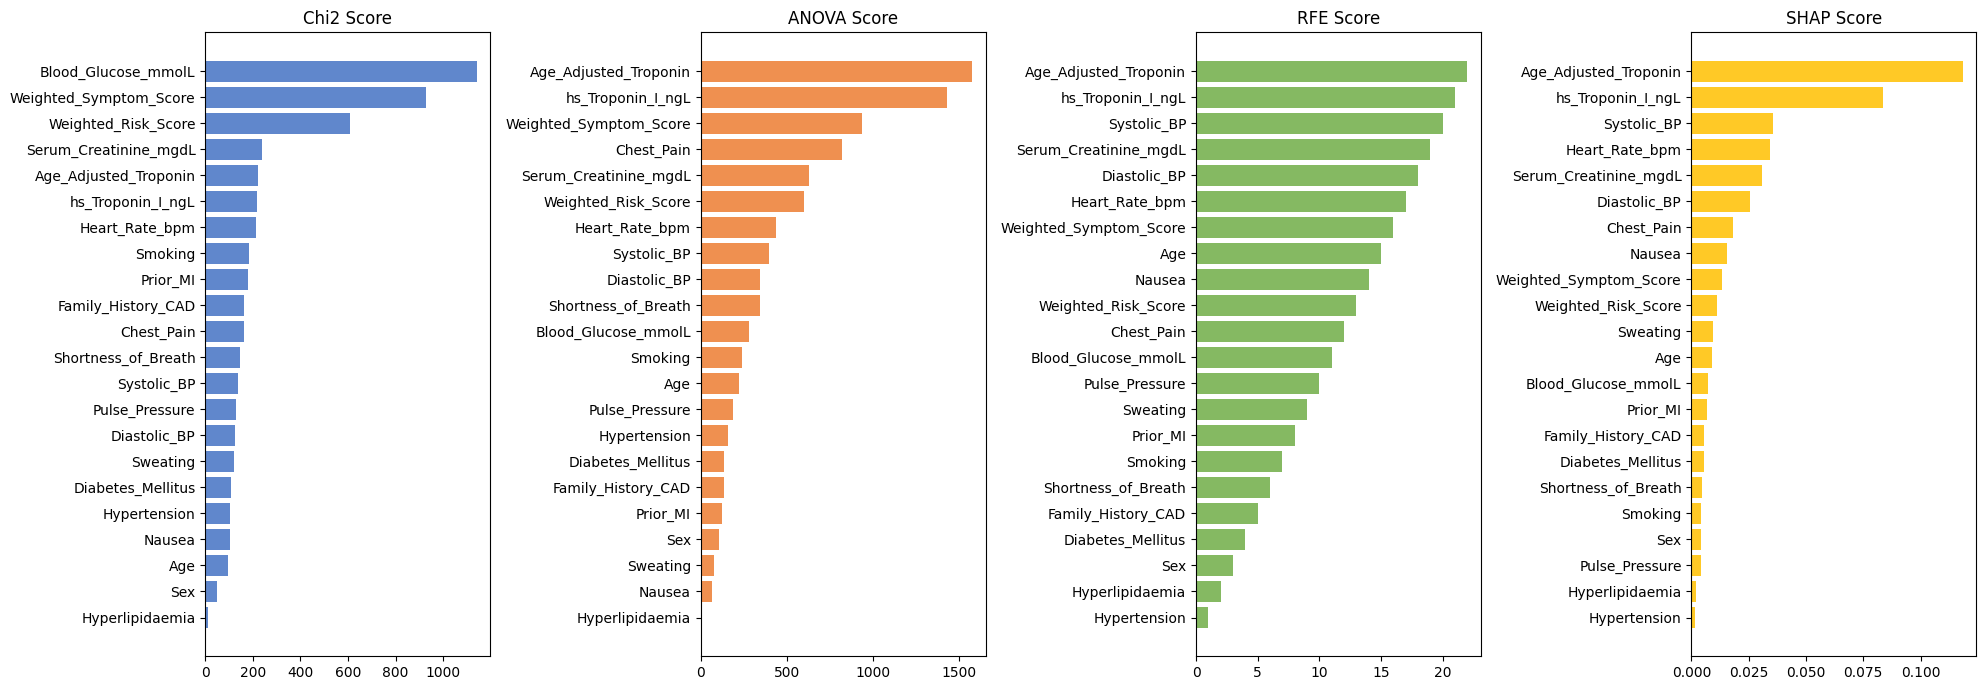

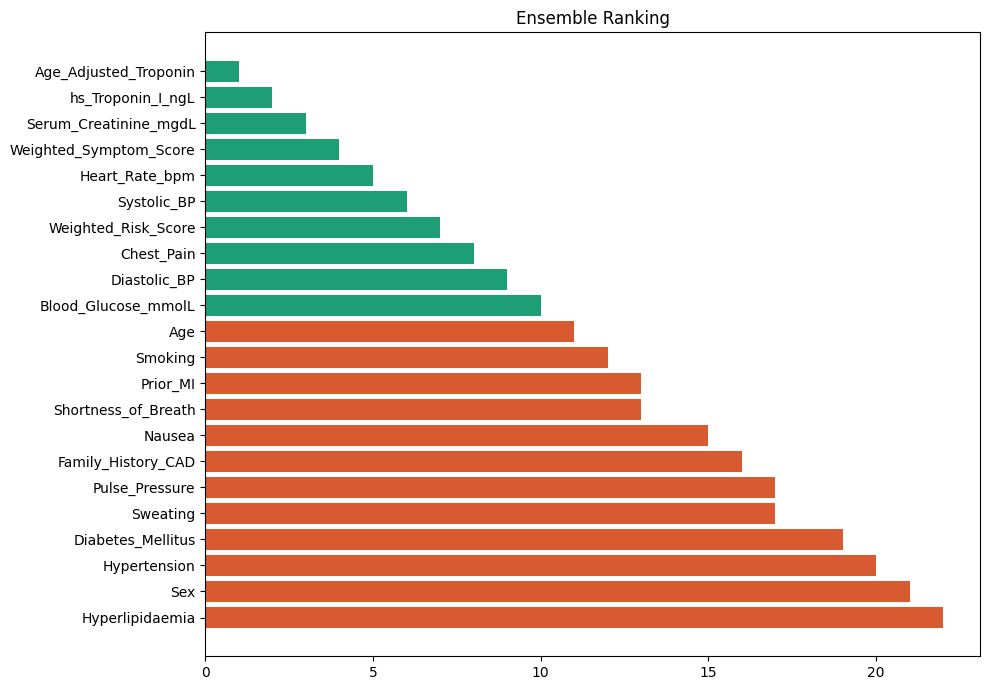


Saved → feature_selection_results.xlsx
Saved → feature_selection_scores.png
Saved → ensemble_ranking.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, chi2, f_classif
from sklearn.preprocessing import LabelEncoder

# =============================================================
# LOAD
# =============================================================

df = pd.read_excel("train_80_smote.xlsx")

# =============================================================
# FEATURES / LABEL
# =============================================================

feature_cols = [c for c in df.columns if c != "Phase"]

X = df[feature_cols].astype(float)

# Encode Phase directly
le = LabelEncoder()
y = le.fit_transform(df["Phase"])

print("Classes:", le.classes_)

# =============================================================
# 1. CHI-SQUARE
# =============================================================

X_pos = X - X.min()

chi2_scores, _ = chi2(X_pos, y)

chi2_series = pd.Series(
    chi2_scores,
    index=feature_cols
)

# =============================================================
# 2. ANOVA
# =============================================================

anova_scores, _ = f_classif(X, y)

anova_series = pd.Series(
    anova_scores,
    index=feature_cols
)

# =============================================================
# 3. RFE
# =============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rf,
    n_features_to_select=1,
    step=1
)

rfe.fit(X, y)

rfe_score = (
    len(feature_cols) + 1 - rfe.ranking_
)

rfe_series = pd.Series(
    rfe_score.astype(float),
    index=feature_cols
)

# =============================================================
# 4. SHAP
# =============================================================

rf_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X, y)

explainer = shap.TreeExplainer(rf_full)

shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):

    shap_mean = np.mean(
        [np.abs(v).mean(axis=0)
         for v in shap_values],
        axis=0
    )

else:

    shap_mean = np.abs(
        shap_values
    ).mean(axis=(0, 2))

shap_series = pd.Series(
    shap_mean,
    index=feature_cols
)

# =============================================================
# 5. SCORE TABLE
# =============================================================

scores_df = pd.DataFrame({

    "Chi2 Score":
        chi2_series.round(2),

    "ANOVA Score":
        anova_series.round(2),

    "RFE Score":
        rfe_series.round(3),

    "SHAP Score":
        shap_series.round(4)

})

print("\n" + "="*70)
print("FEATURE SCORES")
print("="*70)

print(scores_df.to_string())

# =============================================================
# 6. BORDA COUNT
# =============================================================

def rank_series(s):

    return s.rank(
        ascending=False,
        method="min"
    ).astype(int)

ranks_df = pd.DataFrame({

    "Chi2 Rank":
        rank_series(chi2_series),

    "ANOVA Rank":
        rank_series(anova_series),

    "RFE Rank":
        rank_series(rfe_series),

    "SHAP Rank":
        rank_series(shap_series)

})

ranks_df["Borda_Score"] = ranks_df.sum(axis=1)

ranks_df["Ensemble_Rank"] = (
    ranks_df["Borda_Score"]
    .rank(
        ascending=True,
        method="min"
    )
    .astype(int)
)

# =============================================================
# FINAL TABLE
# =============================================================

result_df = pd.concat(
    [scores_df, ranks_df],
    axis=1
)

result_df = result_df.sort_values(
    "Ensemble_Rank"
)

print("\n" + "="*70)
print("ENSEMBLE RANKING")
print("="*70)

print(
    result_df[
        [
            "Chi2 Score",
            "ANOVA Score",
            "RFE Score",
            "SHAP Score",
            "Chi2 Rank",
            "ANOVA Rank",
            "RFE Rank",
            "SHAP Rank",
            "Borda_Score",
            "Ensemble_Rank"
        ]
    ].to_string()
)

# =============================================================
# 7. PLOT
# =============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20,7)
)

plot_data = [

    ("Chi2 Score", "#4472C4"),

    ("ANOVA Score", "#ED7D31"),

    ("RFE Score", "#70AD47"),

    ("SHAP Score", "#FFC000")

]

for ax, (col, color) in zip(
    axes,
    plot_data
):

    s = result_df[col].sort_values()

    ax.barh(
        s.index,
        s.values,
        color=color,
        alpha=0.85
    )

    ax.set_title(col)

plt.tight_layout()

plt.savefig(
    "feature_selection_scores.png",
    dpi=130
)

plt.show()

# =============================================================
# ENSEMBLE PLOT
# =============================================================

fig, ax = plt.subplots(
    figsize=(10,7)
)

s = result_df[
    "Ensemble_Rank"
].sort_values(
    ascending=False
)

colors = [

    "#1D9E75"

    if x <= 10

    else "#D85A30"

    for x in s.values

]

ax.barh(
    s.index,
    s.values,
    color=colors
)

ax.set_title(
    "Ensemble Ranking"
)

plt.tight_layout()

plt.savefig(
    "ensemble_ranking.png",
    dpi=130
)

plt.show()

# =============================================================
# SAVE
# =============================================================

result_df.to_excel(
    "feature_selection_results.xlsx"
)

print("\nSaved → feature_selection_results.xlsx")

print("Saved → feature_selection_scores.png")

print("Saved → ensemble_ranking.png")

In [9]:
# ==============================================================================
# PHASE 1: DATA CLEANING & REFERENCE ARTIFACT LOCKDOWN
# ==============================================================================
import numpy as np 
import pandas as pd 
import os
import joblib

# Load raw clinical dataset
file_path = '/kaggle/input/datasets/iambahar/ffffddddds/MI_NonMI_Patient_Dataset.xlsx'
df = pd.read_excel(file_path)

# 1. Parse Blood Pressure string coordinates
bp = df['Blood_Pressure_mmHg'].astype(str).str.extract(r'(\d+)/(\d+)')
df['Systolic_BP']  = pd.to_numeric(bp[0], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(bp[1], errors='coerce')
df.drop(columns=['Blood_Pressure_mmHg'], inplace=True)
print("[✓] Blood Pressure parsed into Systolic and Diastolic coordinates.")

# 2. Handle missingness structural deletions
drop_cols = [c for c in ['CK_MB_UL', 'BNP_pgmL'] if c in df.columns]
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)

if 'hs_Troponin_I_ngL' in df.columns:
    df = df.dropna(subset=['hs_Troponin_I_ngL']).reset_index(drop=True)

# Define column layout schemas
NUM_COLS_RAW = ['Age', 'hs_Troponin_I_ngL', 'Blood_Glucose_mmolL', 'Serum_Creatinine_mgdL', 'Heart_Rate_bpm', 'Systolic_BP', 'Diastolic_BP']
NUM_COLS_RAW = [c for c in NUM_COLS_RAW if c in df.columns]

CAT_BIN_COLS = ['Sex', 'Chest_Pain', 'Shortness_of_Breath', 'Nausea', 'Sweating', 'Hypertension', 'Diabetes_Mellitus', 'Smoking', 'Hyperlipidaemia', 'Prior_MI', 'Family_History_CAD']

# 3. CRITICAL DEPLOYMENT ARTIFACT: Compute and Save Global Fallback References
# New incoming patient points won't have a known 'Phase', so we save global metrics for live fallback
imputation_references = {"numerical_medians": {}, "categorical_modes": {}}

for col in NUM_COLS_RAW:
    imputation_references["numerical_medians"][col] = float(df[col].median())
for col in CAT_BIN_COLS:
    mode_val = df[col].mode()
    imputation_references["categorical_modes"][col] = str(mode_val.iloc[0]) if not mode_val.empty else "Missing"

joblib.dump(imputation_references, 'training_imputation_references.joblib')
print("[SAVED] Global imputation fallbacks locked to disk.")

# Apply cross-sectional training imputation loops
df_mode = df.copy()
df_missing = df.copy()

for dataset in [df_mode, df_missing]:
    for col in NUM_COLS_RAW:
        if dataset[col].isna().sum() > 0:
            dataset[col] = dataset.groupby(['Phase', 'Sex'])[col].transform(lambda x: x.fillna(x.median()))
            dataset[col] = dataset.groupby('Phase')[col].transform(lambda x: x.fillna(x.median()))
            dataset[col] = dataset[col].fillna(imputation_references["numerical_medians"][col])

for col in CAT_BIN_COLS:
    df_mode[col] = df_mode.groupby(['Phase', 'Sex'])[col].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
    df_mode[col] = df_mode.groupby('Phase')[col].transform(lambda x: x.fillna(x.mode().iloc[0]) if not x.mode().empty else x)
    df_mode[col] = df_mode[col].fillna(df_mode[col].mode().iloc[0])

for col in CAT_BIN_COLS:
    df_missing[col] = df_missing[col].fillna("Missing")

# ==============================================================================
# PHASE 2: PERSISTENT CATEGORICAL ENCODING & FEATURE ENGINEERING
# ==============================================================================
from sklearn.preprocessing import LabelEncoder

fitted_label_encoders = {}

def encode_and_persist(df_target, num_cols, cat_cols):
    df_res = df_target.copy()
    for col in num_cols:
        df_res[col] = pd.to_numeric(df_res[col], errors="coerce").astype(float)
    for col in cat_cols:
        if df_res[col].dtype == object or str(df_res[col].dtype).startswith('str'):
            le = LabelEncoder()
            nan_mask = df_res[col].isna()
            df_res[col] = le.fit_transform(df_res[col].astype(str))
            df_res.loc[nan_mask, col] = np.nan
            fitted_label_encoders[col] = le
        df_res[col] = pd.to_numeric(df_res[col], errors="coerce")
    return df_res

df_mode_encoded = encode_and_persist(df_mode, NUM_COLS_RAW, CAT_BIN_COLS)
joblib.dump(fitted_label_encoders, 'fitted_categorical_encoders.joblib')
print("[SAVED] Categorical label encoder mappings successfully saved.")

# Complete Feature Engineering pipeline steps
SYMPTOM_WEIGHTS = {'Chest_Pain': 4, 'Shortness_of_Breath': 1, 'Nausea': 1, 'Sweating': 1}
RISK_WEIGHTS = {'Prior_MI': 1, 'Hypertension': 1, 'Diabetes_Mellitus': 1, 'Smoking': 1, 'Hyperlipidaemia': 1, 'Family_History_CAD': 1}

df_fe = df_mode_encoded.copy()
df_fe['Pulse_Pressure'] = df_fe['Systolic_BP'] - df_fe['Diastolic_BP']
df_fe['Weighted_Symptom_Score'] = sum(df_fe[col] * w for col, w in SYMPTOM_WEIGHTS.items())
df_fe['Weighted_Risk_Score'] = sum(df_fe[col] * w for col, w in RISK_WEIGHTS.items())
df_fe['Age_Adjusted_Troponin'] = df_fe['Age'] * np.log1p(df_fe['hs_Troponin_I_ngL'])

# ==============================================================================
# PHASE 3: QUANTILE NORMALIZATION CHECKPOINT & SAMPLING SPLITS
# ==============================================================================
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split

continuous_cols = ['Age', 'Heart_Rate_bpm', 'Systolic_BP', 'Diastolic_BP', 'hs_Troponin_I_ngL', 'Pulse_Pressure', 'Age_Adjusted_Troponin']

qt = QuantileTransformer(output_distribution='normal', random_state=42)
df_fe[continuous_cols] = qt.fit_transform(df_fe[continuous_cols])
joblib.dump(qt, 'fitted_quantile_transformer.joblib')
print("[SAVED] Continuous feature Quantile Normalization transformer locked.")

# Partition validation matrices
train_df, temp_df = train_test_split(df_fe, test_size=0.20, stratify=df_fe["Phase"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["Phase"], random_state=42)

# ==============================================================================
# PHASE 4: SMOTE OVERSAMPLING & ENSEMBLE FEATURE SELECTION
# ==============================================================================
from imblearn.over_sampling import SMOTE
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, chi2, f_classif

feature_cols = [c for c in train_df.columns if c != "Phase"]
X_train = train_df[feature_cols].astype(float)
y_train = train_df["Phase"]

# Run class-imbalance oversampling adjustments
class_counts = y_train.value_counts().to_dict()
sampling_strategy = {"Non-MI": class_counts.get("Non-MI", 0), "Chronic": class_counts.get("Chronic", 0), "Sub-acute": 400, "Acute": class_counts.get("Acute", 0)}
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=min(5, min(class_counts.values()) - 1))
X_res, y_res = smote.fit_resample(X_train, y_train)

# Persist Target Class Mappings and Input Schema Configurations
le_target = LabelEncoder()
y_res_encoded = le_target.fit_transform(y_res)
joblib.dump(le_target, 'fitted_target_phase_encoder.joblib')
joblib.dump(feature_cols, 'training_features_schema_list.joblib')
print("[SAVED] Target encoder matrix and structural input feature layouts locked.")

# Feature Ranking Evaluation (Chi2, ANOVA, RFE, SHAP)
X_pos = X_res - X_res.min()
chi2_scores, _ = chi2(X_pos, y_res_encoded)
anova_scores, _ = f_classif(X_res, y_res_encoded)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rf, n_features_to_select=1, step=1).fit(X_res, y_res_encoded)
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_res, y_res_encoded)

explainer = shap.TreeExplainer(rf_full)
shap_values = explainer.shap_values(X_res)
shap_mean = np.mean([np.abs(v).mean(axis=0) for v in shap_values], axis=0) if isinstance(shap_values, list) else np.abs(shap_values).mean(axis=(0, 2))

print("\n" + "="*60)
print(" Pipeline Processing Complete. All Inference Checkpoints Secured.")
print("="*60)


# ==============================================================================
# PHASE 5: LIVE REAL-TIME INFERENCE SINGLE-PATIENT WRAPPER
# ==============================================================================
def preprocess_single_point(raw_data_dict, artifacts_dir="."):
    """
    Transforms a single raw incoming clinical patient dictionary observation point 
    using the exact locked pipeline parameters extracted during original training.
    """
    refs = joblib.load(f"{artifacts_dir}/training_imputation_references.joblib")
    encoders = joblib.load(f"{artifacts_dir}/fitted_categorical_encoders.joblib")
    quantile_transformer = joblib.load(f"{artifacts_dir}/fitted_quantile_transformer.joblib")
    expected_features = joblib.load(f"{artifacts_dir}/training_features_schema_list.joblib")
    
    symptom_weights = {'Chest_Pain': 4, 'Shortness_of_Breath': 1, 'Nausea': 1, 'Sweating': 1}
    risk_weights = {'Prior_MI': 1, 'Hypertension': 1, 'Diabetes_Mellitus': 1, 'Smoking': 1, 'Hyperlipidaemia': 1, 'Family_History_CAD': 1}
    
    proc = raw_data_dict.copy()
    if "Blood_Pressure_mmHg" in proc:
        try:
            sys_val, dia_val = str(proc["Blood_Pressure_mmHg"]).split('/')
            proc["Systolic_BP"] = float(sys_val)
            proc["Diastolic_BP"] = float(dia_val)
        except Exception:
            proc["Systolic_BP"] = np.nan
            proc["Diastolic_BP"] = np.nan
        del proc["Blood_Pressure_mmHg"]

    for col in ["CK_MB_UL", "BNP_pgmL"]:
        if col in proc: del proc[col]
            
    # Apply continuous/categorical default fallbacks safely
    for col, fallback_median in refs["numerical_medians"].items():
        if col not in proc or pd.isna(proc[col]): proc[col] = fallback_median
    for col, fallback_mode in refs["categorical_modes"].items():
        if col not in proc or pd.isna(proc[col]) or proc[col] == "": proc[col] = fallback_mode

    # Run persistent encoders
    for col, encoder_obj in encoders.items():
        if col in proc:
            val_str = str(proc[col])
            proc[col] = int(encoder_obj.transform([val_str])[0]) if val_str in encoder_obj.classes_ else int(encoder_obj.transform([encoder_obj.classes_[0]])[0])

    single_row_df = pd.DataFrame([proc])

    # Dynamic feature engineering
    single_row_df['Pulse_Pressure'] = single_row_df['Systolic_BP'] - single_row_df['Diastolic_BP']
    single_row_df['Weighted_Symptom_Score'] = sum(single_row_df[col] * w for col, w in symptom_weights.items())
    single_row_df['Weighted_Risk_Score'] = sum(single_row_df[col] * w for col, w in risk_weights.items())
    single_row_df['Age_Adjusted_Troponin'] = single_row_df['Age'] * np.log1p(single_row_df['hs_Troponin_I_ngL'])

    # Map onto exact continuous normal distributions from training session
    continuous_layout = ['Age', 'Heart_Rate_bpm', 'Systolic_BP', 'Diastolic_BP', 'hs_Troponin_I_ngL', 'Pulse_Pressure', 'Age_Adjusted_Troponin']
    single_row_df[continuous_layout] = quantile_transformer.transform(single_row_df[continuous_layout])

    return single_row_df[expected_features].astype(float)




[✓] Blood Pressure parsed into Systolic and Diastolic coordinates.
[SAVED] Global imputation fallbacks locked to disk.
[SAVED] Categorical label encoder mappings successfully saved.
[SAVED] Continuous feature Quantile Normalization transformer locked.
[SAVED] Target encoder matrix and structural input feature layouts locked.

 Pipeline Processing Complete. All Inference Checkpoints Secured.


In [12]:
def predict_phase_with_biomedbert(processed_matrix_df, model, tokenizer, class_names, device="cuda"):
    """
    Takes the processed dataframe matrix output from preprocess_single_point,
    filters the top 10 features, serializes them to a text string,
    and runs inference through BioMedBERT.
    """
    model.eval()
    
    # 1. Define the top 10 features exactly as your ensemble ranked them
    selected_features = [
        "Blood_Glucose_mmolL",
        "Diastolic_BP",
        "Chest_Pain",
        "Weighted_Risk_Score",
        "Systolic_BP",
        "Heart_Rate_bpm",
        "Weighted_Symptom_Score",
        "Serum_Creatinine_mgdL",
        "hs_Troponin_I_ngL",
        "Age_Adjusted_Troponin"
    ]
    
    # 2. Extract the single row as a dictionary series
    patient_row = processed_matrix_df.iloc[0]
    
    # 3. Filter down and keep only the top 10 columns in order
    filtered_features = {f: patient_row[f] for f in selected_features if f in patient_row}
    
    # 4. Serialize the normalized coordinates into text format
    # Using float formatting to keep the string tokens clean for BioMedBERT
    serialized_text = " | ".join([f"{col}:{val:.4f}" for col, val in filtered_features.items()])
    print("\n" + "="*70)
    print(" GENERATED INFERENCE TEXT FOR BIOMEDBERT")
    print("="*70)
    print(f"{serialized_text}\n")
    
    # 5. Tokenize text input sequence
    inputs = tokenizer(
        serialized_text, 
        padding="max_length", 
        truncation=True, 
        max_length=256, 
        return_tensors="pt"
    ).to(device)
    
    # 6. Run model forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]
        
    # 7. Match max probability to string label
    predicted_class_idx = np.argmax(probabilities)
    predicted_label = class_names[predicted_class_idx]
    
    # 8. Compile confidence breakdown
    confidence_breakdown = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
    
    print(f"Diagnostic Decision -> [ {predicted_label} ]")
    print("\nConfidence Matrix:")
    for phase, prob in confidence_breakdown.items():
        print(f"  {phase:<12}: {prob * 100:.2f}%")
        
    return predicted_label, confidence_breakdown

# ==============================================================================
# EXECUTING THE COMPLETE INFRASTRUCTURE PIPELINE LOOP
# ==============================================================================
# 1. Process the raw patient entry into the standardized matrix format
processed_point = preprocess_single_point(sample_raw_patient, artifacts_dir=".")

# 2. Pass the processed matrix straight to your Transformer for diagnostic categorization
predicted_phase, scores = predict_phase_with_biomedbert(
    processed_matrix_df=processed_point,
    model=model,
    tokenizer=tokenizer,
    class_names=CLASS_NAMES,
    device=DEVICE
)

NameError: name 'model' is not defined